### Threat Classification for Wildlife Reserve



In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [21]:
model = nn.Sequential(
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,64),
    nn.ReLU(),
    nn.Linear(64,1)
)


print(model)

Sequential(
  (0): Linear(in_features=128, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)




---



In [22]:
data = np.array([2,3,4,4,5])

tensor_data = torch.tensor(data,dtype=torch.float32)

print(tensor_data)

tensor([2., 3., 4., 4., 5.])




---



In [23]:
logits = torch.tensor([[1.0, 2.0, 0.5], [1.5, 0.2, 1.7], [0.4, 0.8, 2.1]], dtype=torch.float32)

labels = torch.tensor([1, 2, 0], dtype=torch.long)

loss_fun = nn.CrossEntropyLoss()

loss = loss_fun(logits,labels)

print(f"Cross-Entropy Loss: {loss.item():.4f}")

Cross-Entropy Loss: 1.0845




---



In [5]:
df = pd.read_csv("habitat_images_codebasics_DL.csv")
df.head()

,Image Brightness,Movement Intensity,Number of Shapes Detected,Noise Level,Threat Label
0,0.437086,0.314292,19,0.186741,0
1,0.955643,6.364104,10,4.113003,0
2,0.758795,3.143560,16,1.800953,0
3,0.638793,5.085707,7,0.635303,0
4,0.240417,9.075665,3,2.611216,0


In [24]:
df = pd.read_csv("habitat_images_codebasics_DL.csv")

X = df[["Image Brightness","Movement Intensity","Number of Shapes Detected","Noise Level"]].values
y = df["Threat Label"].values



---



**Normalizing the input feature**

In [7]:
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))



---



***Converting to PyTorch tensors***


In [8]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # Reshape to match the model output



---



In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)



---



**Creating DataLoader for batch processing**

In [10]:
train_data = TensorDataset(X_train,y_train)
test_data = TensorDataset(X_test,y_test)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)



---



In [11]:
next(iter(train_loader))

[tensor([[0.1043, 0.7897, 0.8421, 1.0000],
         [0.7403, 0.3141, 0.8421, 0.3543],
         [0.9827, 0.1576, 0.8947, 0.5391],
         [0.8118, 0.1835, 0.6842, 0.9485],
         [0.5243, 0.5065, 0.1053, 0.4710],
         [0.0939, 0.7112, 0.9474, 0.4151],
         [0.1533, 0.2476, 0.2632, 0.7741],
         [0.7800, 0.3393, 0.9474, 0.8084],
         [0.3259, 0.7370, 0.0000, 0.5007],
         [0.3113, 0.2565, 0.3158, 0.3120],
         [0.5291, 0.1835, 0.4211, 0.7999],
         [0.3120, 0.6157, 0.1579, 0.7061],
         [0.1941, 0.7711, 0.6842, 0.3690],
         [0.7945, 0.4293, 0.3684, 0.4042],
         [0.7212, 0.9096, 0.7895, 0.6296],
         [0.6295, 0.1088, 0.1053, 0.0820]]),
 tensor([[1.],
         [0.],
         [0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.]])]

In [12]:
class ThreatDetector(nn.Module):
    def __init__(self):
        super(ThreatDetector, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4,8),    # Input: 4 features, Hidden layer: 8 neurons
            nn.ReLU(),         # Activation: ReLU
            nn.Linear(8,1),   # Output: 1 neuron
            nn.Sigmoid()        # Activation: Sigmoid (for binary classification)
        )

    def forward(self, x):
        return self.network(x)

model = ThreatDetector()




---



In [13]:
BCE_loss = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr=0.01)



---



In [14]:
def train_model(model, train_loader, BCE_loss, optimizer, epochs=20):
    model.train()
    
    for epoch in range(epochs):
        epoch_loss = 0
        for images,labels in train_loader:
                # Forward pass
                outputs = model(images)
                loss = BCE_loss(outputs,labels)
                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                # loss
                epoch_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

train_model(model, train_loader, BCE_loss, optimizer, epochs=20)


Epoch 1/20, Loss: 0.6254
Epoch 2/20, Loss: 0.5351
Epoch 3/20, Loss: 0.4860
Epoch 4/20, Loss: 0.5088
Epoch 5/20, Loss: 0.4630
Epoch 6/20, Loss: 0.4525
Epoch 7/20, Loss: 0.4479
Epoch 8/20, Loss: 0.4361
Epoch 9/20, Loss: 0.3872
Epoch 10/20, Loss: 0.4067
Epoch 11/20, Loss: 0.3945
Epoch 12/20, Loss: 0.4076
Epoch 13/20, Loss: 0.3442
Epoch 14/20, Loss: 0.3919
Epoch 15/20, Loss: 0.3185
Epoch 16/20, Loss: 0.3238
Epoch 17/20, Loss: 0.2879
Epoch 18/20, Loss: 0.2738
Epoch 19/20, Loss: 0.2680
Epoch 20/20, Loss: 0.2841




---



Accuracy: 1.00


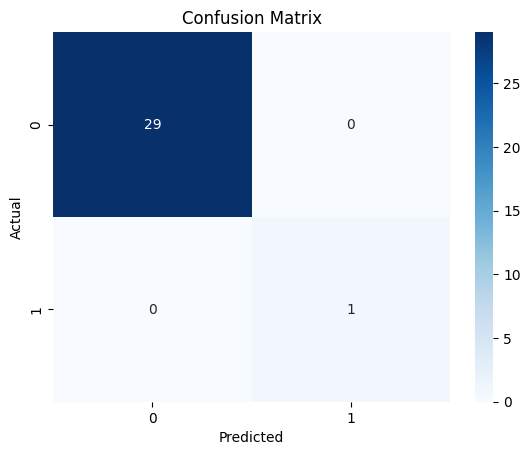

In [20]:
def evaluate_model(model, test_loader):
   
    all_predicted = []
    all_correct = []
    model.eval()
    with torch.no_grad():
        for images,labels in test_loader:
            outputs = model(images)
            all_correct.extend(labels.numpy())
            all_predicted.extend(outputs.numpy())
    # Convert predictions to binary (threshold = 0.5)
    predicted_binary = [1 if correct > 0.5 else 0 for correct in all_correct]

    # Accuracy
    accuracy = accuracy_score(all_correct,predicted_binary)
    print(f"Accuracy: {accuracy:.2f}")

    #Confusion Matrix
    cm = confusion_matrix(all_correct,predicted_binary)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# Evaluate the model
evaluate_model(model, test_loader)




---

